In [23]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

In [24]:
# def bisection_method(func, a, b, eps):
#     func_a, func_b = func(a), func(b)
#     while np.abs(a - b) > eps:
#         mid = (a + b) / 2
#         func_mid = func(mid)
#         if (func_mid > 0 and func_a < 0) or (func_mid < 0 and func_a > 0):
#             b = mid
#             func_b = func_mid
#         else:
#             a = mid
#             func_a = func_mid
#     return (a + b) / 2

In [25]:
def compute_threshold(alpha, delta_L, delta_U, K_max, psi_star, v_min):
    D_L = psi_star(delta_L)
    D_U = psi_star(delta_U)
    def f(g):
        ks = np.arange(1, K_max + 1)
        return np.min(ks * np.exp(-g*np.pow(D_U / D_L, -1/ks)))
    def f2(g):
        return f(g) - alpha
    if f(v_min * D_U) <= alpha:
        return brentq(f2, np.log(1/alpha), v_min * D_U)
        # return bisection_method(f2, np.log(1/alpha), v_min * D_U, eps)
    else:
        return brentq(f2, v_min * D_U, (D_U / D_L) * np.log(2/alpha))
        # return bisection_method(f2, v_min * D_U, (D_U / D_L) * np.log(2/alpha), eps)

In [26]:
def compute_baseline(alpha, delta_L, delta_U, K_max, psi_star, psi_star_grad, v_min):
    D_L = psi_star(delta_L)
    D_U = psi_star(delta_U)
    lambda_L = psi_star_grad(delta_L)
    lambda_U = psi_star_grad(delta_U)
    if np.log(1/alpha) <= v_min * D_L:
        return np.array([lambda_L]), np.ones(1), None
    g_alpha = compute_threshold(alpha, delta_L, delta_U, K_max, psi_star, v_min)
    ks = np.arange(1, K_max + 1)
    K_alpha = np.argmin(ks * np.exp(-g_alpha * np.pow(D_U / D_L, -1/ks))) + 1
    eta_alpha = (D_U / D_L) ** (1 / K_alpha)
    lambdas = np.zeros(K_alpha + 1)
    lambdas[0] = lambda_U
    lambdas[K_alpha] = lambda_L
    for k in range(1, K_alpha):
        delta_k = brentq(lambda z: psi_star(z) - D_U * eta_alpha ** (-k), delta_L, delta_U)
        lambdas[k] = psi_star_grad(delta_k)
    W = np.exp(-g_alpha) * (1 if g_alpha > v_min * D_U else 0) + K_alpha * np.exp(-g_alpha / eta_alpha)
    omegas = np.zeros_like(lambdas)
    omegas[0] = (np.exp(-g_alpha) * (1 if g_alpha > v_min * D_U else 0)) / W
    for k in range(1, K_alpha + 1):
        omegas[k] = np.exp(-g_alpha / eta_alpha) / W

    return lambdas, omegas, (g_alpha, K_alpha, eta_alpha, W)


In [27]:
class eSR_Mixture:
    def __init__(self, alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min):
        self.alpha = alpha
        lambdas, omegas, params = compute_baseline(alpha, delta_L, delta_U, K_max, psi_star_func, psi_star_grad, v_min)
        self.lambdas = lambdas
        self.omegas = omegas
        self.g_alpha = None
        self.eta_alpha = None
        self.W = None
        if params:
            self.g_alpha = params[0]
            self.eta_alpha = params[2]
            self.W = params[3]
        self.K_alpha = len(lambdas) - 1
        self.M_SR = np.zeros(self.K_alpha + 1)
        self.psi = np.array([psi_func(lam) for lam in self.lambdas])
        self.s_func = s_func
        self.v_func = v_func
        self.n = 0


    def observe(self, X):
        self.n += 1
        self.M_SR = np.exp(self.lambdas * self.s_func(X) - self.psi * self.v_func(X)) * (self.M_SR + 1)
        mM_SR = np.dot(self.omegas, self.M_SR)
        if mM_SR >= 1 / self.alpha:
            return self.n, mM_SR
        return None, mM_SR

class eCU_Mixture:
    def __init__(self, alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min):
        self.alpha = alpha
        lambdas, omegas, params = compute_baseline(alpha, delta_L, delta_U, K_max, psi_star_func, psi_star_grad, v_min)
        self.lambdas = lambdas
        self.omegas = omegas
        self.g_alpha = None
        self.eta_alpha = None
        self.W = None
        if params:
            self.g_alpha = params[0]
            self.eta_alpha = params[2]
            self.W = params[3]
        self.K_alpha = len(lambdas) - 1
        self.M_CU = np.zeros(self.K_alpha + 1)
        self.psi = np.array([psi_func(lam) for lam in self.lambdas])
        self.s_func = s_func
        self.v_func = v_func
        self.n = 0


    def observe(self, X):
        self.n += 1
        self.M_CU = np.exp(self.lambdas * self.s_func(X) - self.psi * self.v_func(X)) * np.max([self.M_CU, np.ones_like(self.M_CU)], axis=0)
        mM_CU = np.dot(self.omegas, self.M_CU)
        if mM_CU >= 1 / self.alpha:
            return self.n, mM_CU
        return None, mM_CU


### Bernoulli example

In [28]:
alpha = 0.001
p = 0.49
delta_L= 0.02
delta_U = 0.41
K_max = 1000

In [29]:
def make_psi_functions(p):
    def psi(x):
        return np.log(1 - p + p * np.exp(x)) - x * p
    def psi_star(delta):
        q = delta + p
        return q * np.log(q / p) + (1 - q) * np.log((1 - q) / (1 - p))
    def psi_star_grad(delta):
        q = delta + p
        return np.log(q / p) - np.log((1 - q) / (1 - p))
    def s(x):
        return x - p
    def v(x):
        return 1

    return psi, psi_star, psi_star_grad, s, v


psi_func, psi_star_func, psi_star_grad, s_func, v_func = make_psi_functions(p)

#### E-SR and E-CUSUM with no change in data

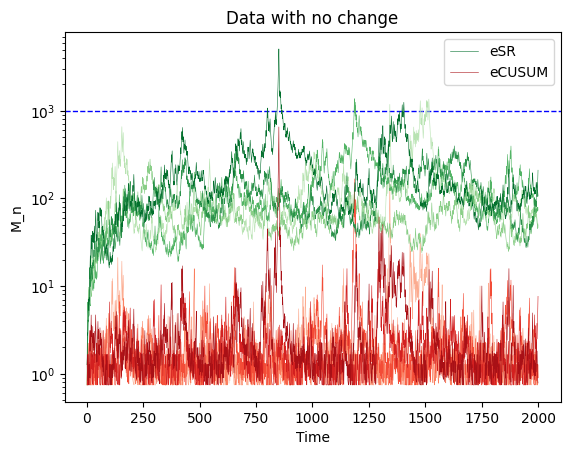

In [30]:
np.random.seed(42)


N = 100
pre_data_len = 400
N_plot = 5

n_parts_after_change = 4


data_streams = np.zeros(shape=(N, pre_data_len * (n_parts_after_change + 1)))
for step in range(N):
    pre_p = np.random.uniform(0.45, 0.49, pre_data_len)
    pre_change_data = np.random.binomial(1, pre_p)
    post_p = np.random.uniform(0.45, 0.49, pre_data_len * n_parts_after_change)
    post_change_data = np.random.binomial(1, post_p)

    data_streams[step] = np.concat([pre_change_data, post_change_data])


delays_SR = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))
delays_CU = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))

plt.axhline(y=1/alpha, linestyle='--', color='b', linewidth=1)

for step in range(N):
    achieved_SR = False
    achieved_CU = False
    SR_detector = eSR_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
    CU_detector = eCU_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
    mMSRs = []
    mMCUs = []
    cmap_SR = plt.cm.Greens
    cmap_CU = plt.cm.Reds

    data_stream = data_streams[step]
    for i, result in enumerate(data_stream):
        decision_SR, mM_SR = SR_detector.observe(result)
        decision_CU, mM_CU = CU_detector.observe(result)
        if step < N_plot:
            mMSRs.append(mM_SR)
            mMCUs.append(mM_CU)

        if (not achieved_SR) and (decision_SR is not None):
            delays_SR[step] = decision_SR
            achieved_SR = True

        if (not achieved_CU) and (decision_CU is not None):
            delays_CU[step] = decision_CU
            achieved_CU = True

    if step < N_plot:
        plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMSRs, color=cmap_SR(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eSR' if step == N_plot - 1 else "")
        plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMCUs, color=cmap_CU(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eCUSUM' if step ==  N_plot - 1 else "")

plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('M_n')
plt.title(f"Data with no change")

plt.legend()
plt.show()

In [31]:
print(f"Average run length with eSR >= {delays_SR.mean()}")

Average run length with eSR >= 1521.99


In [32]:
print(f"Average run length with eCUSUM >= {delays_CU.mean()}")

Average run length with eCUSUM >= 1983.14


#### E-SR and E-CUSUM with change in data

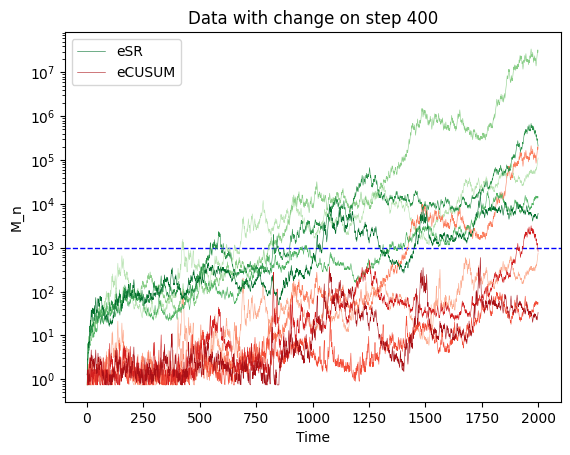

In [33]:
np.random.seed(42)


N = 100
pre_data_len = 400
N_plot = 5


data_streams = np.zeros(shape=(N, pre_data_len * (n_parts_after_change + 1)))
for step in range(N):
    pre_p = np.random.uniform(0.45, 0.49, pre_data_len)
    pre_change_data = np.random.binomial(1, pre_p)
    post_p = np.random.uniform(0.51, 0.55, pre_data_len * n_parts_after_change)
    post_change_data = np.random.binomial(1, post_p)

    data_streams[step] = np.concat([pre_change_data, post_change_data])


delays_SR = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))
delays_CU = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))

plt.axhline(y=1/alpha, linestyle='--', color='b', linewidth=1)
for step in range(N):
    achieved_SR = False
    achieved_CU = False
    SR_detector = eSR_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
    CU_detector = eCU_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
    mMSRs = []
    mMCUs = []
    cmap_SR = plt.cm.Greens
    cmap_CU = plt.cm.Reds

    data_stream = data_streams[step]
    for i, result in enumerate(data_stream):
        decision_SR, mM_SR = SR_detector.observe(result)
        decision_CU, mM_CU = CU_detector.observe(result)
        if step < N_plot:
            mMSRs.append(mM_SR)
            mMCUs.append(mM_CU)

        if (not achieved_SR) and (decision_SR is not None):
            delays_SR[step] = decision_SR
            achieved_SR = True

        if (not achieved_CU) and (decision_CU is not None):
            delays_CU[step] = decision_CU
            achieved_CU = True

    if step < N_plot:
        plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMSRs, color=cmap_SR(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eSR' if step == N_plot - 1 else "")
        plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMCUs, color=cmap_CU(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eCUSUM' if step ==  N_plot - 1 else "")

plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('M_n')
plt.title(f"Data with change on step {pre_data_len}")

plt.legend()
plt.show()

In [34]:
print(f"Average delay with eSR >= {delays_SR.mean() - pre_data_len - 1}")

Average delay with eSR >= 261.96000000000004


In [35]:
print(f"Average delay with eCUSUM >= {delays_CU.mean() - pre_data_len - 1}")

Average delay with eCUSUM >= 1231.3


### Quantile change detection example

#### 1) Bernoulli again

In [36]:
import scipy.stats as ss

In [37]:
alpha = 0.001
p = 0.05
C = 1.96
delta_L= 0.02
delta_U = 0.2
K_max = 1000

In [38]:
def make_psi_functions(p, C):
    def psi(x):
        return np.log(1 - p + p * np.exp(x)) - x * p
    def psi_star(delta):
        q = delta + p
        return q * np.log(q / p) + (1 - q) * np.log((1 - q) / (1 - p))
    def psi_star_grad(delta):
        q = delta + p
        return np.log(q / p) - np.log((1 - q) / (1 - p))
    def s(x):
        return (1 if abs(x) > C else 0) - p
    def v(x):
        return 1

    return psi, psi_star, psi_star_grad, s, v


psi_func, psi_star_func, psi_star_grad, s_func, v_func = make_psi_functions(p, C)

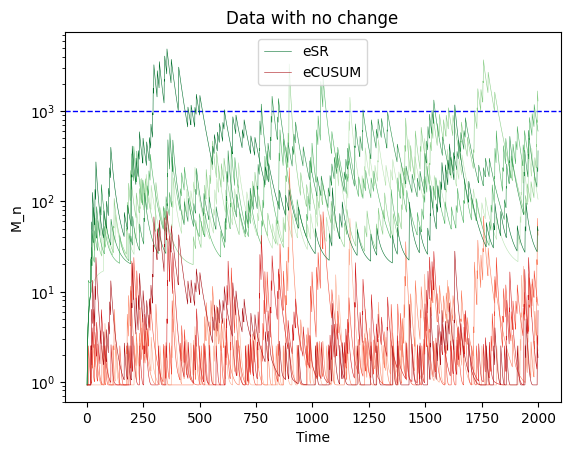

In [39]:
np.random.seed(42)


N = 100
pre_data_len = 400
N_plot = 5

n_parts_after_change = 4


data_streams = np.zeros(shape=(N, pre_data_len * (n_parts_after_change + 1)))
for step in range(N):
    pre_change_data = np.random.normal(0, 1, pre_data_len)
    post_change_data = np.random.normal(0, 1, pre_data_len * n_parts_after_change)

    data_streams[step] = np.concat([pre_change_data, post_change_data])


delays_SR = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))
delays_CU = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))

plt.axhline(y=1/alpha, linestyle='--', color='b', linewidth=1)

for step in range(N):
    achieved_SR = False
    achieved_CU = False
    SR_detector = eSR_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
    CU_detector = eCU_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
    mMSRs = []
    mMCUs = []
    cmap_SR = plt.cm.Greens
    cmap_CU = plt.cm.Reds

    data_stream = data_streams[step]
    for i, result in enumerate(data_stream):
        decision_SR, mM_SR = SR_detector.observe(result)
        decision_CU, mM_CU = CU_detector.observe(result)
        if step < N_plot:
            mMSRs.append(mM_SR)
            mMCUs.append(mM_CU)

        if (not achieved_SR) and (decision_SR is not None):
            delays_SR[step] = decision_SR
            achieved_SR = True

        if (not achieved_CU) and (decision_CU is not None):
            delays_CU[step] = decision_CU
            achieved_CU = True

    if step < N_plot:
        plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMSRs, color=cmap_SR(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eSR' if step == N_plot - 1 else "")
        plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMCUs, color=cmap_CU(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eCUSUM' if step ==  N_plot - 1 else "")

plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('M_n')
plt.title(f"Data with no change")

plt.legend()
plt.show()

In [40]:
print(f"Average run length with eSR >= {delays_SR.mean()}")

Average run length with eSR >= 1014.19


In [41]:
print(f"Average run length with eCU >= {delays_CU.mean()}")

Average run length with eCU >= 1932.61


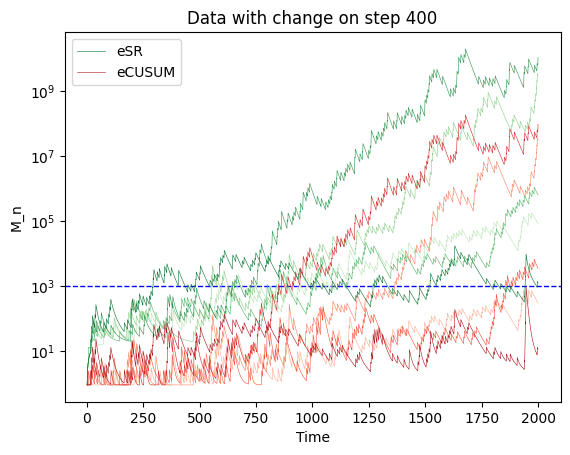

In [42]:
np.random.seed(42)


N = 100
pre_data_len = 400
N_plot = 5

n_parts_after_change = 4


data_streams = np.zeros(shape=(N, pre_data_len * (n_parts_after_change + 1)))
for step in range(N):
    pre_change_data = np.random.normal(0, 1, pre_data_len)
    post_change_data = np.random.normal(0, 1.1, pre_data_len * n_parts_after_change)

    data_streams[step] = np.concat([pre_change_data, post_change_data])


delays_SR = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))
delays_CU = np.ones(N, dtype=int) * (pre_data_len * (n_parts_after_change + 1))

plt.axhline(y=1/alpha, linestyle='--', color='b', linewidth=1)

for step in range(N):
    achieved_SR = False
    achieved_CU = False
    SR_detector = eSR_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
    CU_detector = eCU_Mixture(alpha, delta_L, delta_U, K_max, psi_func, psi_star_func, psi_star_grad, s_func, v_func, v_min=1)
    mMSRs = []
    mMCUs = []
    cmap_SR = plt.cm.Greens
    cmap_CU = plt.cm.Reds

    data_stream = data_streams[step]
    for i, result in enumerate(data_stream):
        decision_SR, mM_SR = SR_detector.observe(result)
        decision_CU, mM_CU = CU_detector.observe(result)
        if step < N_plot:
            mMSRs.append(mM_SR)
            mMCUs.append(mM_CU)

        if (not achieved_SR) and (decision_SR is not None):
            delays_SR[step] = decision_SR
            achieved_SR = True

        if (not achieved_CU) and (decision_CU is not None):
            delays_CU[step] = decision_CU
            achieved_CU = True

    if step < N_plot:
        plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMSRs, color=cmap_SR(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eSR' if step == N_plot - 1 else "")
        plt.plot(np.arange(1, pre_data_len * (n_parts_after_change + 1)  + 1), mMCUs, color=cmap_CU(0.3 + step / N_plot * 0.7), linewidth=0.4, label='eCUSUM' if step ==  N_plot - 1 else "")

plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('M_n')
plt.title(f"Data with change on step 400")

plt.legend()
plt.show()

In [43]:
print(f"Average delay with eSR >= {delays_SR.mean() - pre_data_len - 1}")

Average delay with eSR >= 123.57000000000005


In [44]:
print(f"Average delay with eCU >= {delays_CU.mean() - pre_data_len - 1}")

Average delay with eCU >= 896.53
